This section applies RFM(Recency,Frequency,Monetary)analysis to segment customers based on purchasing behaviour. The goal is to identify high-value, loyal, and at-risk customers for targeted marketing strategies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
df= pd.read_csv('master_cleaned_dataset.csv')
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

In [3]:
rfm_df= (
    df[['customer_unique_id',
        'order_id',
        'order_purchase_timestamp',
        'total_order_value']]
    .drop_duplicates()
)

In [4]:
snapshot_data = rfm_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

In [5]:
rfm= rfm_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x:(snapshot_data - x.max()).days,
    'order_id': 'count',
    'total_order_value': 'sum'
}).reset_index()

In [6]:
rfm.columns= ['customer_unique_id', 'Recency', 'Frequency', 'Monetary']

In [7]:
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


In [8]:
rfm['R_score']= pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])

In [9]:
rfm['F_score']= pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])

In [10]:
rfm['M_score']= pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

In [11]:
rfm['RFM_Score']= (
    rfm['R_score'].astype(str)+
    rfm['F_score'].astype(str)+
    rfm['M_score'].astype(str)
)

In [12]:
def segment_customer(row):
    if row['R_score'] >= 4 and row['F_score'] >= 4:
        return 'Loyal'
    elif row['R_score'] >= 4 and row['F_score'] <= 2:
        return 'New'
    elif row['R_score']>= 2 and row['F_score'] >= 4:
        return 'At Risk'
    else:
        return 'Standard'
rfm['Segment']= rfm.apply(segment_customer, axis=1)

In [13]:
segment_counts= rfm['Segment'].value_counts()

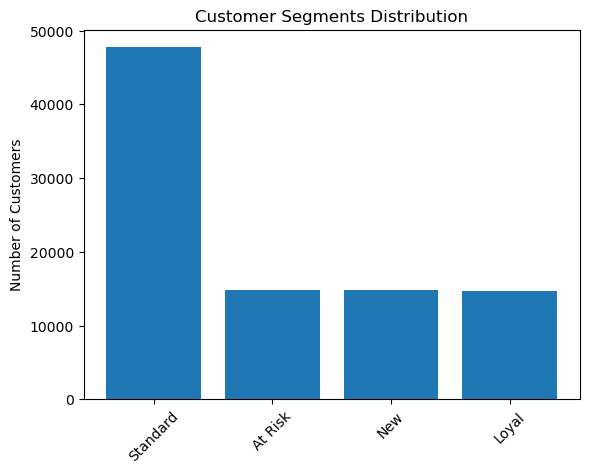

In [14]:
plt.figure()
plt.bar(segment_counts.index, segment_counts.values)
plt.title('Customer Segments Distribution')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

RFM segmentation reveals distinct behavioural customer groups. Loyal customers represent high-frequency, recent purchasers and are key revenue drivers. At-risk customers demonstrate declining recency despite historical engagement, suggesting retention intervention opportunites. This segmentation framework supports targeted marketing and customer lifecycle strategies.

In [16]:
segment_revenue= (
    rfm.groupby('Segment')
    .agg({
        'customer_unique_id':'count',
        'Monetary':'sum'
    })
    .reset_index()
)

segment_revenue.rename(columns={
    'customer_unique_id':'Customer_Count',
    'Monetary': 'Total_Revenue'
}, inplace=True)

In [17]:
segment_revenue['Revenue_Share_%'] = (
    segment_revenue['Total_Revenue']/
    segment_revenue['Total_Revenue'].sum()
)* 100

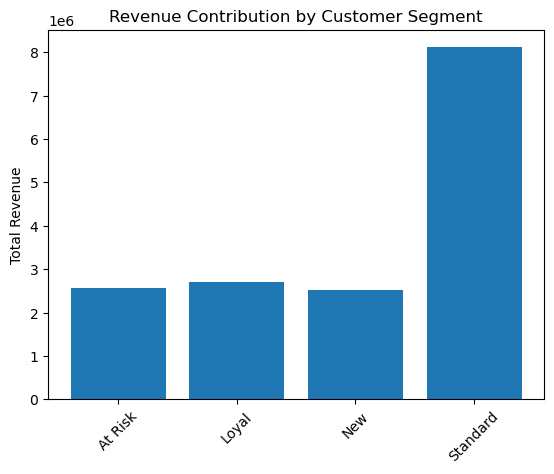

In [18]:
plt.figure()
plt.bar(segment_revenue['Segment'],
        segment_revenue['Total_Revenue'])
plt.title('Revenue Contribution by Customer Segment')
plt.ylabel('Total Revenue')
plt.xticks(rotation= 45)
plt.show()

Revenue contribution analysis reveals disproportionate value concentration across segments. Loyal customers generate a significantly higher share of total revenue relative to their population size, highlighting the importance of retention strategies. Conversely, lower engagement segments contribute less revenue and represent opportunities for targeted reactivation campaigns.

In [19]:
rfm.to_csv('rfm_dataset.csv', index=False)